In [7]:
import os.path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tqdm

# Variables

In [15]:
data_dir = os.path.join('..', 'data')
gmdb_root_dir = 'V:\\GestaltMatcher\\v1.1.0'
gmdb_data_file = os.path.join(data_dir, 'gmdb_data.csv')
gmdb_data_extended_file = os.path.join(data_dir, 'gmdb_hpo_facemesh_data.csv')
hpo_data_file = os.path.join(data_dir, 'Face2HPO-181120251320.csv')
fma_csv = os.path.join(data_dir, 'face_mesh_annotations_merged.csv')

df = pd.read_csv(gmdb_data_file, low_memory=False)

# Face Mesh Annotation + HPO Annotation Pre-Processing

In [4]:
print('Merge manual HPO annotations into gmdb file...')

hpo_df = pd.read_csv(hpo_data_file)
columns = ['image_id', 'present_hpo_terms', 'absent_hpo_terms']
redundancy_mask = hpo_df['image_id'].duplicated(keep='first')
duplicates_df = hpo_df[redundancy_mask]
result = {k: [] for k in columns}
for idx, row in duplicates_df.iterrows():
    duplicate_rows = hpo_df[hpo_df['image_id'] == row['image_id']]
    row1 = duplicate_rows.iloc[0]
    row2 = duplicate_rows.iloc[1]

    result['image_id'].append(row['image_id'])
    for column in list(result.keys())[1:]:
        value1 = row1[column].split(' ') if isinstance(row1[column], str) else np.NaN
        value2 = row2[column].split(' ') if isinstance(row2[column], str) else np.NaN
        merged_values = value1 if isinstance(value1, list) else value2
        if isinstance(value1, list) and isinstance(value2, list):
            merged_values = list(set(value1 + value2))
        result[column].append(merged_values)

for idx, image_id in tqdm.tqdm(enumerate(result['image_id'])):
    for column in list(result.keys())[1:]:
        hpo_list = ' '.join(result[column][idx])
        hpo_df.loc[hpo_df['image_id'] == image_id, column] = hpo_list
hpo_df.drop_duplicates(subset=['image_id'], inplace=True, keep='first')
hpo_df.drop(columns=['user_id', 'username', 'patient_id', 'omim_id'], inplace=True)

hpo_df = hpo_df[columns]

# columns = [c for c in df.columns if not c.isdigit() and not c.startswith('HP:')]
columns = ['image_id', 'present_features', 'absent_features', 'present_hpo_terms', 'absent_hpo_terms']
gmdb_df = pd.read_csv(gmdb_data_file)
df = pd.merge(gmdb_df, hpo_df, on='image_id', how='left')

print('Done!')

1581


C:\Users\hellmafa\AppData\Local\Temp\ipykernel_9476\2265098260.py:33: DtypeWarning: Columns (3325,3326,3327,3333,3337,3338,3341,3342,3345,3348) have mixed types. Specify dtype option on import or set low_memory=False.
  gmdb_df = pd.read_csv(gmdb_data_file)


['WILLIAMS-BEUREN SYNDROME; WBS',
 'Cornelia de Lange syndrome',
 'Hypoplastic left heart syndrome',
 'Kabuki syndrome',
 'Noonan syndrome',
 'Noonan syndrome-like disorder with loose anagen hair',
 'KBG SYNDROME; KBGS',
 'Coffin-Siris syndrome',
 'SCHAAF-YANG SYNDROME; SHFYNG',
 'Mucopolysaccharidoses',
 'Hyperphosphatasia with mental retardation syndrome',
 'OGDEN SYNDROME; OGDNS']

In [13]:
def merge_features(row):
    # Helper to split strings safely into sets
    def split_to_set(value, sep):
        if pd.isna(value):
            return set()
        return set(s.strip() for s in str(value).split(sep) if s.strip())

    # Parse present_features and absent_features (semicolon separated)
    present_feats = split_to_set(row['present_features'], ';')
    absent_feats = split_to_set(row['absent_features'], ';')

    # Parse present_hpo_terms and absent_hpo_terms (space separated)
    present_hpo = split_to_set(row['present_hpo_terms'], ' ')
    absent_hpo = split_to_set(row['absent_hpo_terms'], ' ')

    # Add present_hpo terms to present_features if not already in absent_features
    new_present = {term for term in present_hpo if term not in absent_feats}
    present_absent_overlap = {term for term in present_hpo if term in absent_feats}

    # Add absent_hpo terms to absent_features if not already in present_features
    new_absent = {term for term in absent_hpo if term not in present_feats}
    absent_present_overlap = {term for term in absent_hpo if term in present_feats}

    # Merge and convert back to semicolon-separated strings
    merged_present = present_feats.union(new_present)
    merged_absent = absent_feats.union(new_absent)
    merged_present_absent_overlap = present_feats.union(present_absent_overlap)
    merged_absent_present_overlap = absent_feats.union(absent_present_overlap)

    row['present_features'] = ';'.join(sorted(merged_present)) if merged_present else np.nan
    row['absent_features'] = ';'.join(sorted(merged_absent)) if merged_absent else np.nan
    row['present_in_absent_dropped'] = ';'.join(sorted(merged_present_absent_overlap)) if merged_absent_present_overlap else np.nan
    row['absent_in_present_dropped'] = ';'.join(sorted(merged_absent_present_overlap)) if merged_absent_present_overlap else np.nan

    return row

# Assuming df is the merged dataframe with the target columns:
df_merged = df.apply(merge_features, axis=1)
df_merged.to_csv(gmdb_data_extended_file)

In [14]:
print('Merge manual facemesh annotations into gmdb+hpo file...')
fma_df = pd.read_csv(fma_csv)
manual_columns = [f'manual_{i}' for i in range(478*3)]
df_all = df_merged.copy()
df_all[manual_columns] = np.nan
mesh_coordinates = []
for _, row in tqdm.tqdm(fma_df.iterrows(), total=len(fma_df)):
    mesh_coordinates.append(np.asarray([np.asarray([m['x'], m['y'], m['z']]) for m in json.loads(row['facemesh'])]).flatten())
for idx, row in tqdm.tqdm(fma_df.iterrows(), total=len(fma_df)):
    df_all.loc[df_all['image_id'] == row['image_id'], manual_columns] = mesh_coordinates[idx]
df_all.drop(columns=['Unnamed: 0', 'features_present'], inplace=True)
df_all.drop(df_all.filter(regex='HP:*').columns, axis=1, inplace=True)
df_all.to_csv(gmdb_data_extended_file)
print('Done!')
df_all

Merge manual facemesh annotations into gmdb file...


C:\Users\hellmafa\AppData\Local\Temp\ipykernel_9476\1889655747.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_all[manual_columns] = np.nan
C:\Users\hellmafa\AppData\Local\Temp\ipykernel_9476\1889655747.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_all[manual_columns] = np.nan
C:\Users\hellmafa\AppData\Local\Temp\ipykernel_9476\1889655747.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all col

Done!


,Unnamed: 0,image_id,features_present,HP:0002786,HP:0011039,HP:0000508,HP:0040326,HP:0010761,HP:0010506,HP:0100712,...,1429,1430,1431,1432,1433,age,present_hpo_terms,absent_hpo_terms,present_in_absent_dropped,absent_in_present_dropped
0,0,1,True,0,0,0,0,0,0,0,...,-0.024471,0.001842,0.027176,-0.019063,0.003132,NaN,HP:0000293,NaN,NaN,NaN
1,1,2,True,0,0,0,0,0,0,0,...,-0.024379,0.003135,0.031430,-0.020276,0.004023,NaN,HP:0000154 HP:0000179 HP:0000293,HP:0410030 HP:0000160 HP:0000219,NaN,NaN
2,2,3,True,0,0,0,0,0,0,0,...,-0.023688,0.002989,0.032844,-0.020259,0.005429,NaN,HP:0000293,NaN,NaN,NaN
3,3,4,False,0,0,0,0,0,0,0,...,-0.020558,0.002997,0.030811,-0.016346,0.001081,12.0,HP:0000294 HP:0000290 HP:0000341 HP:0002007 HP...,HP:0009890 HP:0000337 HP:0000348 HP:0000574 HP...,NaN,NaN
4,4,5,False,0,0,0,0,0,0,0,...,-0.028301,0.001288,0.027229,-0.023575,0.002038,83.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6740,6740,9378,False,0,0,0,0,0,0,0,...,-0.016259,0.004645,0.034336,-0.013898,0.005245,16.0,HP:0009890 HP:0000290 HP:0000337 HP:0000348 HP...,HP:0000294 HP:0000341 HP:0045075 HP:0002223 HP...,NaN,NaN
6741,6741,9380,False,0,0,0,0,0,0,0,...,-0.022630,-0.007039,0.025630,-0.017129,-0.008328,1.0,HP:0000322 HP:0005280 HP:0000233 HP:0002007 HP...,HP:0000455 HP:0004493 HP:0410030 HP:0000581 HP...,NaN,NaN
6742,6742,9381,False,0,0,0,0,0,0,0,...,-0.024894,0.000818,0.027853,-0.020434,0.001742,8.0,HP:0005280 HP:0000431 HP:0000325 HP:0000337 HP...,HP:0410030 HP:0000347 HP:0000278 HP:0000303 HP...,NaN,NaN
6743,6743,9384,False,0,0,0,0,0,0,0,...,-0.028552,0.001132,0.024036,-0.023551,0.002103,4.0,NaN,NaN,NaN,NaN


# Extract Subsets from Datasets

## Overlap of HPOs & FaceMesh-Annotations

In [52]:
result_df = pd.read_csv(gmdb_data_extended_file)
mask = (result_df['present_hpo_terms'].notna() | result_df['absent_hpo_terms'].notna()) & result_df['manual_0'].notna()
overlap_df = result_df[mask]
overlap_df[['image_id', 'present_features', 'absent_features', 'present_hpo_terms', 'absent_hpo_terms', 'manual_0']]

C:\Users\hellmafa\AppData\Local\Temp\ipykernel_9476\692082662.py:1: DtypeWarning: Columns (6,7,8,14,18,19,23,26,29,1471,1472,1473,1474) have mixed types. Specify dtype option on import or set low_memory=False.
  result_df = pd.read_csv(gmdb_data_extended_file)


,image_id,present_features,absent_features,present_hpo_terms,absent_hpo_terms,manual_0
0,1,HP:0000293;HP:0000343;HP:0000436;HP:0000629;HP...,NaN,HP:0000293,NaN,0.499553
6,8,HP:0000293,HP:0410030,HP:0000293,HP:0410030,0.504468
9,13,HP:0000293;HP:0000348;HP:0000486,HP:0000232;HP:0000275;HP:0000278;HP:0000280;HP...,HP:0000293 HP:0000348 HP:0000486,HP:0410030 HP:0000232 HP:0010803 HP:0000347 HP...,0.510771
12,18,HP:0000154;HP:0000179;HP:0000275;HP:0000280;HP...,HP:0000160;HP:0000219;HP:0000232;HP:0000233;HP...,HP:0045075 HP:0100539 HP:0000286 HP:0000494 HP...,HP:0000574 HP:0002223 HP:0000664 HP:0000336 HP...,0.505062
15,23,HP:0000316;HP:0000341;HP:0000348;HP:0000486;HP...,HP:0000286;HP:0000294;HP:0000336;HP:0000337;HP...,HP:0009890 HP:0000341 HP:0000348 HP:0002007 HP...,HP:0000294 HP:0000337 HP:0000574 HP:0002223 HP...,0.499087
...,...,...,...,...,...,...
6640,9204,HP:0000160;HP:0000219;HP:0000233;HP:0000275;HP...,HP:0000154;HP:0000179;HP:0000232;HP:0000278;HP...,HP:0000160 HP:0000233 HP:0000219 HP:0010803 HP...,HP:0410030 HP:0000154 HP:0012471 HP:0000179 HP...,0.508280
6642,9207,HP:0000118;HP:0000152;HP:0000160;HP:0000219;HP...,HP:0000154;HP:0000179;HP:0000232;HP:0000275;HP...,HP:0000160 HP:0002714 HP:0000233 HP:0000219 HP...,HP:0410030 HP:0000154 HP:0010805 HP:0012471 HP...,0.503257
6645,9213,HP:0000574;HP:0011231,HP:0045075;HP:0410030,HP:0000574 HP:0011231,HP:0045075 HP:0410030,0.508721
6647,9217,HP:0000219;HP:0000233;HP:0000289;HP:0000290;HP...,HP:0000179;HP:0000232;HP:0000275;HP:0000280;HP...,HP:0002714 HP:0000233 HP:0000219 HP:0010803 HP...,HP:0410030 HP:0010805 HP:0012471 HP:0000179 HP...,0.497615


## Only HPOs + GMDB - exclude Overlap

In [50]:
result_df = pd.read_csv(gmdb_data_extended_file)
mask = (result_df['present_features'].notna() | result_df['absent_features'].notna() | result_df['present_hpo_terms'].notna() | result_df['absent_hpo_terms'].notna()) & result_df['manual_0'].isna()
only_hpo_df = result_df[mask]
only_hpo_df[['image_id', 'present_features', 'absent_features', 'present_hpo_terms', 'absent_hpo_terms', 'manual_0']]

C:\Users\hellmafa\AppData\Local\Temp\ipykernel_9476\4044767235.py:1: DtypeWarning: Columns (6,7,8,14,18,19,23,26,29,1471,1472,1473,1474) have mixed types. Specify dtype option on import or set low_memory=False.
  result_df = pd.read_csv(gmdb_data_extended_file)


,image_id,present_features,absent_features,present_hpo_terms,absent_hpo_terms,manual_0
1,2,HP:0000154;HP:0000179;HP:0000293;HP:0000687;HP...,HP:0000160;HP:0000219;HP:0410030,HP:0000154 HP:0000179 HP:0000293,HP:0410030 HP:0000160 HP:0000219,NaN
2,3,HP:0000154;HP:0000179;HP:0000293;HP:0000448;HP...,NaN,HP:0000293,NaN,NaN
3,4,HP:0000290;HP:0000294;HP:0000316;HP:0000336;HP...,HP:0000286;HP:0000337;HP:0000348;HP:0000520;HP...,HP:0000294 HP:0000290 HP:0000341 HP:0002007 HP...,HP:0009890 HP:0000337 HP:0000348 HP:0000574 HP...,NaN
135,187,HP:0000154;HP:0000179;HP:0000232;HP:0000275;HP...,HP:0000160;HP:0000219;HP:0000286;HP:0000294;HP...,HP:0000154 HP:0000232 HP:0000179 HP:0000275 HP...,HP:0410030 HP:0000160 HP:0000219 HP:0010803 HP...,NaN
144,196,HP:0000054;HP:0000568;HP:0000629;HP:0001328;HP...,NaN,HP:0000568 HP:0000054,NaN,NaN
...,...,...,...,...,...,...
6614,9152,HP:0000998;HP:0001250;HP:0001263;HP:0001385;HP...,NaN,NaN,NaN,NaN
6734,9354,HP:0000252;HP:0000486;HP:0000657;HP:0001263;HP...,NaN,NaN,NaN,NaN
6741,9380,HP:0000160;HP:0000219;HP:0000232;HP:0000233;HP...,HP:0000154;HP:0000179;HP:0000275;HP:0000280;HP...,HP:0000322 HP:0005280 HP:0000233 HP:0002007 HP...,HP:0000455 HP:0004493 HP:0410030 HP:0000581 HP...,NaN
6742,9381,HP:0000286;HP:0000316;HP:0000325;HP:0000337;HP...,HP:0000275;HP:0000278;HP:0000280;HP:0000293;HP...,HP:0005280 HP:0000431 HP:0000325 HP:0000337 HP...,HP:0410030 HP:0000347 HP:0000278 HP:0000303 HP...,NaN


## Only FaceMesh + GMDB - exclude Overlap

In [49]:
result_df = pd.read_csv(gmdb_data_extended_file)
mask = (result_df['present_features'].notna() | result_df['absent_features'].notna()) & result_df['present_hpo_terms'].isna() & result_df['absent_hpo_terms'].isna() & result_df['manual_0'].notna()
only_fm_df = result_df[mask]
only_fm_df[['image_id', 'present_features', 'absent_features', 'present_hpo_terms', 'absent_hpo_terms', 'manual_0']]

C:\Users\hellmafa\AppData\Local\Temp\ipykernel_9476\1987122125.py:1: DtypeWarning: Columns (6,7,8,14,18,19,23,26,29,1471,1472,1473,1474) have mixed types. Specify dtype option on import or set low_memory=False.
  result_df = pd.read_csv(gmdb_data_extended_file)


,image_id,present_features,absent_features,present_hpo_terms,absent_hpo_terms,manual_0
142,194,HP:0000629;HP:0001328;HP:0001518;HP:0004209;HP...,NaN,NaN,NaN,0.502627
143,195,HP:0000629;HP:0001328;HP:0001518;HP:0004209;HP...,NaN,NaN,NaN,0.525502
149,201,HP:0000154;HP:0000343;HP:0000455;HP:0000629;HP...,NaN,NaN,NaN,0.498615
152,204,HP:0000286;HP:0000331;HP:0000414;HP:0000472;HP...,NaN,NaN,NaN,0.512258
153,206,HP:0000324,NaN,NaN,NaN,0.494130
...,...,...,...,...,...,...
6054,8345,HP:0000256;HP:0000337;HP:0000365;HP:0000494;HP...,NaN,NaN,NaN,0.536493
6573,9098,HP:0000303;HP:0000324;HP:0000494;HP:0000767;HP...,NaN,NaN,NaN,0.494584
6576,9101,HP:0000160;HP:0000256;HP:0000276;HP:0000307;HP...,NaN,NaN,NaN,0.497164
6577,9102,HP:0000160;HP:0000256;HP:0000276;HP:0000307;HP...,NaN,NaN,NaN,0.524714


## Visualize combined Subsets within GMDB

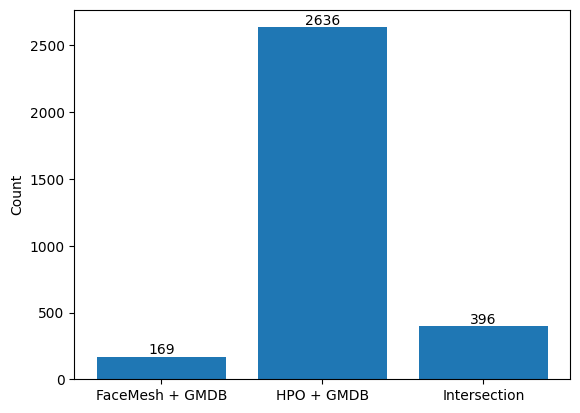

In [53]:
bars = ['FaceMesh + GMDB', 'HPO + GMDB', 'Intersection']
counts = [len(only_fm_df), len(only_hpo_df), len(overlap_df)]
plt.bar(bars, counts)
plt.ylabel('Count')

# Add values on top of bars
for i, count in enumerate(counts):
    plt.text(i, count + 0.05, str(count), ha='center', va='bottom')

plt.show()